In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.ticker import FormatStrFormatter
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit

from utils import *
np.random.seed(42)

In [2]:
SetStyle()

# Let's check the ABCD hypothesis by loading QCD Simulated events and comparing the ABCD prediction with the real distribution

In [3]:
size = 'l'
pred_type = "NP"
observable = 'mass'
sort_type = "pt"
year = "2016"
signal_name = "dihiggs_dijet"
data_folder = "/pscratch/sd/v/vmikuni/Omnilearned/"

eff = 0.002
get_eff_cut = True
if observable == 'dimass':
    bin = np.linspace(1000,1600,20)
else:
    bin = np.linspace(60,240,20)

In [4]:
if get_eff_cut:
    data_plot = EventData.from_npz_folder(name="data",pred_type=pred_type,sort_type="pt",region_type="SR",
                                          folder=data_folder,pattern=f"outputs_pretrain_{size}_jetht_dijet.npz",
                                          observable=observable)
    cut = np.quantile(np.min(data_plot.prediction[data_plot.base_mask],1), 1.0 - eff)
    print(f"The cut threshold for eff {eff} is: {cut}")

The cut threshold for eff 0.002 is: 0.9017606973648071


/tmp/ipykernel_856946/4052366830.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


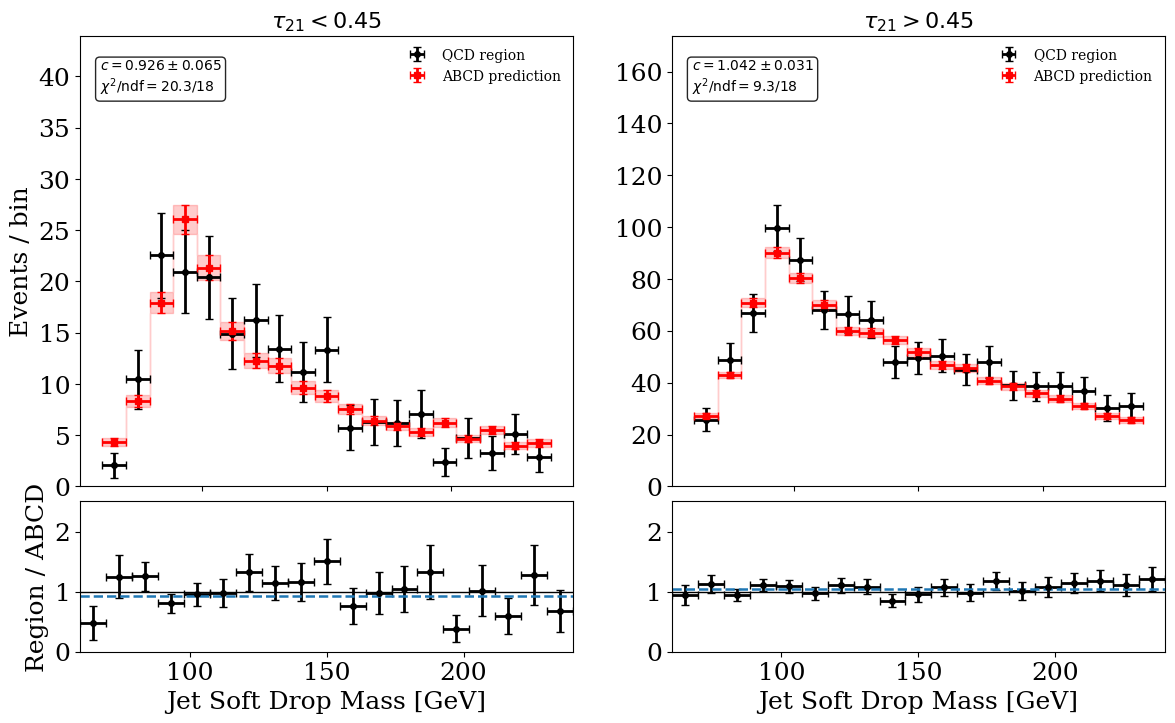

In [5]:
def _constant(x, c):
    return np.full_like(x, c, dtype=float)


def _constant(x, c):
    return np.full_like(x, c, dtype=float)


def _hist_and_err(x, w, bins):
    vals, _ = np.histogram(x, bins=bins, weights=w)
    sw2, _ = np.histogram(x, bins=bins, weights=w**2)
    return vals, np.sqrt(sw2), sw2


def compare_abcd(
    bin_edges,
    cut,
    pred_type,
    sort_type,
    size,
    observable,
    year,
    plot_prefix="qcd_abcd_comparison",
):
    fig, axs = plt.subplots(
        2, 2, figsize=(14, 8),
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
    )

    tags = ["SR", "VR1"]
    titles = {
        "SR":  r"$\tau_{21} < 0.45$",
        "VR1": r"$\tau_{21} > 0.45$",
    }

    fit_results = {}
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = bin_edges[1:] - bin_edges[:-1]

    for i, tag in enumerate(tags):
        ax = axs[0, i]
        axr = axs[1, i]

        data = EventData.from_npz_folder(
            "data",
            pred_type,
            sort_type,
            tag,
            data_folder,
            f"outputs_pretrain_{size}_qcd600_dijet.npz",
            observable=observable,
        )

        mask_sr, mask_cr1, mask_cr3, mask_cr2 = abcd_pred(
            data.prediction[:, 0],
            data.prediction[:, 1],
            cut,
            cut,
            data.mask,
        )

        w = 20 * data.weight("nom")[:, 0]
        x = data.obs[:, 0]

        sr_vals, sr_err, sr_sw2 = _hist_and_err(x[mask_sr],  w[mask_sr],  bin_edges)
        cr1_vals, _, cr1_sw2   = _hist_and_err(x[mask_cr1], w[mask_cr1], bin_edges)
        cr2_vals, _, cr2_sw2   = _hist_and_err(x[mask_cr2], w[mask_cr2], bin_edges)
        cr3_vals, _, cr3_sw2   = _hist_and_err(x[mask_cr3], w[mask_cr3], bin_edges)

        with np.errstate(divide="ignore", invalid="ignore"):
            abcd_vals = np.where(cr3_vals > 0, cr1_vals * cr2_vals / cr3_vals, 0.0)
            abcd_err = np.where(
                cr3_vals > 0,
                abcd_vals * np.sqrt(
                    cr1_sw2 / (cr1_vals**2 + 1e-10) +
                    cr2_sw2 / (cr2_vals**2 + 1e-10) +
                    cr3_sw2 / (cr3_vals**2 + 1e-10)
                ),
                0.0,
            )

        ax.errorbar(
            bin_centers, sr_vals,
            xerr=bin_widths / 2, yerr=sr_err,
            fmt="ko", ms=4, capsize=3, label="QCD region"
        )
        ax.errorbar(
            bin_centers, abcd_vals,
            xerr=bin_widths / 2, yerr=abcd_err,
            fmt="rs", ms=4, capsize=3, label="ABCD prediction"
        )
        ax.fill_between(
            np.repeat(bin_edges, 2)[1:-1],
            np.repeat(abcd_vals - abcd_err, 2),
            np.repeat(abcd_vals + abcd_err, 2),
            color="red", alpha=0.2
        )

        valid = (sr_vals > 0) & (abcd_vals > 0)
        ratio = np.zeros_like(sr_vals)
        ratio_err = np.zeros_like(sr_vals)

        ratio[valid] = sr_vals[valid] / abcd_vals[valid]
        ratio_err[valid] = ratio[valid] * np.sqrt(
            sr_sw2[valid] / (sr_vals[valid]**2 + 1e-10) +
            abcd_err[valid]**2 / (abcd_vals[valid]**2 + 1e-10)
        )

        axr.axhline(1.0, color="black", lw=1)
        axr.errorbar(
            bin_centers[valid], ratio[valid],
            xerr=bin_widths[valid] / 2, yerr=ratio_err[valid],
            fmt="ko", ms=4, capsize=3
        )

        fit_label = "fit failed"
        if np.any(valid):
            fit_x = bin_centers[valid]
            fit_y = ratio[valid]
            fit_e = np.where(ratio_err[valid] > 0, ratio_err[valid], 1e-10)

            try:
                popt, pcov = curve_fit(
                    _constant, fit_x, fit_y,
                    sigma=fit_e, absolute_sigma=True, p0=[1.0]
                )
                c_fit = popt[0]
                c_err = np.sqrt(pcov[0, 0]) if pcov.size else np.nan
                chi2 = np.sum(((fit_y - c_fit) / fit_e) ** 2)
                ndf = len(fit_y) - 1

                axr.axhline(c_fit, linestyle="--", linewidth=1.8, label="Best Fit")

                fit_results[tag] = {"c": c_fit, "c_err": c_err, "chi2": chi2, "ndf": ndf}
                fit_label = (
                    rf"$c = {c_fit:.3f} \pm {c_err:.3f}$" "\n"
                    rf"$\chi^2 / \mathrm{{ndf}} = {chi2:.1f}/{ndf}$"
                )
            except RuntimeError:
                fit_results[tag] = None
        else:
            fit_results[tag] = None

        ymax = max(np.max(sr_vals + sr_err), np.max(abcd_vals + abcd_err), 1.0)
        ax.set_ylim(0, 1.6 * ymax)

        ax.set_title(titles[tag], fontsize=16)
        ax.text(
            0.04, 0.95, fit_label,
            transform=ax.transAxes,
            va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        )
        ax.legend(fontsize=10)
        axr.set_ylim(0.0, 2.5)
        axr.set_xlim(bin_edges[0], bin_edges[-1])

        if i == 0:
            ax.set_ylabel("Events / bin")
            axr.set_ylabel("Region / ABCD")

        axr.set_xlabel("Jet Soft Drop Mass [GeV]")
        plt.setp(ax.get_xticklabels(), visible=False)

    os.makedirs("plots", exist_ok=True)
    plt.tight_layout()
    plt.savefig(f"plots/{plot_prefix}_{pred_type}_{size}_{year}.pdf", bbox_inches="tight")
    plt.show()

    return fit_results

fit_results = compare_abcd(
    bin_edges=bin,
    cut=cut,
    pred_type=pred_type,
    sort_type=sort_type,
    size=size,
    observable=observable,
    year=year,
)